<a href="https://colab.research.google.com/github/burningdust/ESAA/blob/main/YB_assignment/ESAA_YB_study5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 코드 필사

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()

%matplotlib inline

pd.options.mode.chained_assignment = None # default = 'warn'

In [2]:
file_path = "/content/drive/MyDrive/이화여자대학교/ESAA/과제/data/"
order_products_train_df = pd.read_csv(file_path + "order_products__train.csv")
order_products_prior_df = pd.read_csv(file_path + "order_products__prior.csv")
orders_df = pd.read_csv(file_path + "orders.csv")
products_df = pd.read_csv(file_path + "products.csv")
aisles_df = pd.read_csv(file_path + "aisles.csv")
departments_df = pd.read_csv(file_path + "departments.csv")

In [3]:
orders_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [4]:
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [5]:
order_products_train_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


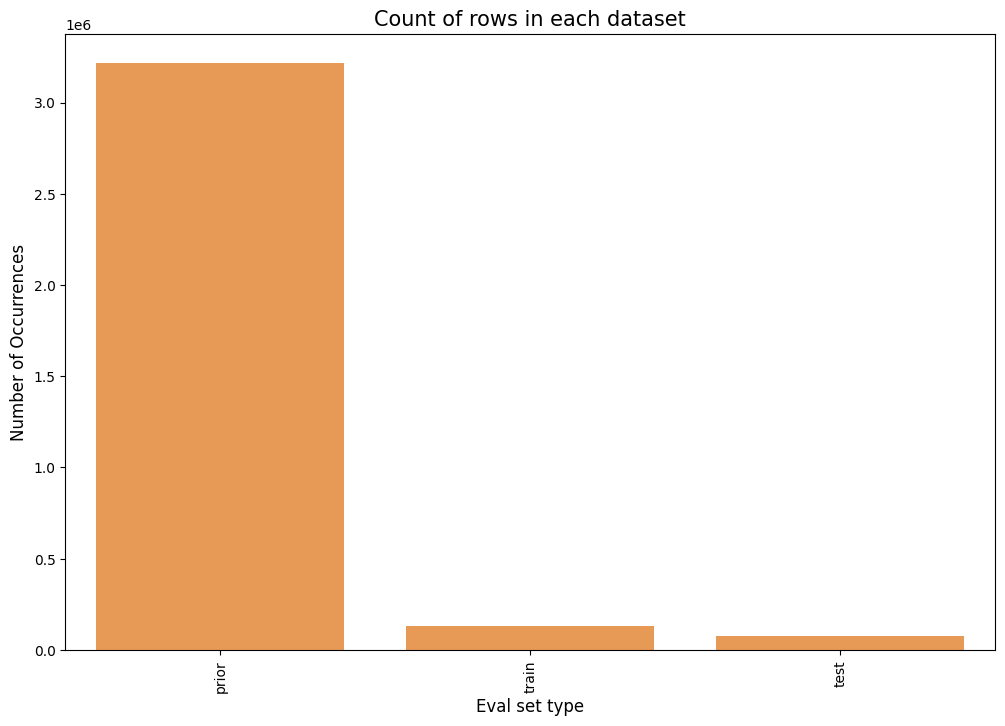

In [6]:
cnt_srs = orders_df.eval_set.value_counts()

plt.figure(figsize = (12, 8))
sns.barplot(x = cnt_srs.index, y = cnt_srs.values, alpha = 0.8, color = color[1])
plt.ylabel('Number of Occurrences', fontsize = 12)
plt.xlabel('Eval set type', fontsize = 12)
plt.title('Count of rows in each dataset', fontsize = 15)
plt.xticks(rotation = 'vertical')
plt.show()

In [7]:
def get_unique_count(x):
  return len(np.unique(x))

cnt_srs = orders_df.groupby("eval_set")["user_id"].aggregate(get_unique_count)
cnt_srs

,user_id
eval_set,
prior,206209
test,75000
train,131209


/tmp/ipykernel_14107/2918188613.py:1: FutureWarning: The provided callable <function max at 0x789d81b18a40> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  cnt_srs = orders_df.groupby("user_id")["order_number"].aggregate(np.max).reset_index()


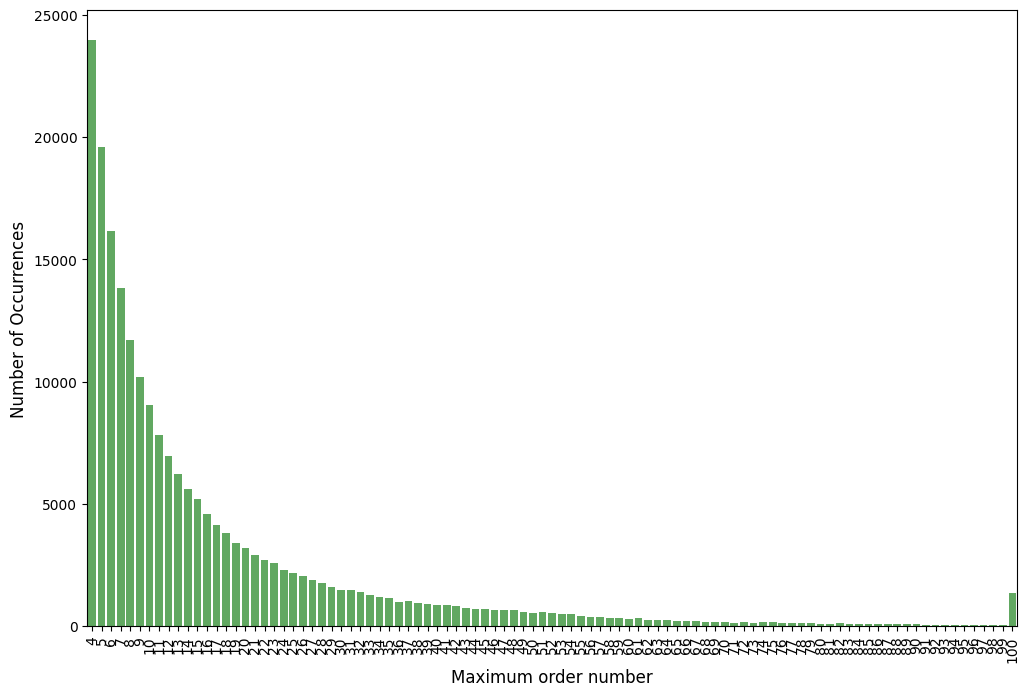

In [8]:
cnt_srs = orders_df.groupby("user_id")["order_number"].aggregate(np.max).reset_index()
cnt_srs = cnt_srs.order_number.value_counts()

plt.figure(figsize = (12, 8))
sns.barplot(x = cnt_srs.index, y = cnt_srs.values, alpha = 0.8, color = color[2])
plt.ylabel("Number of Occurrences", fontsize = 12)
plt.xlabel("Maximum order number", fontsize = 12)
plt.xticks(rotation = "vertical")
plt.show()

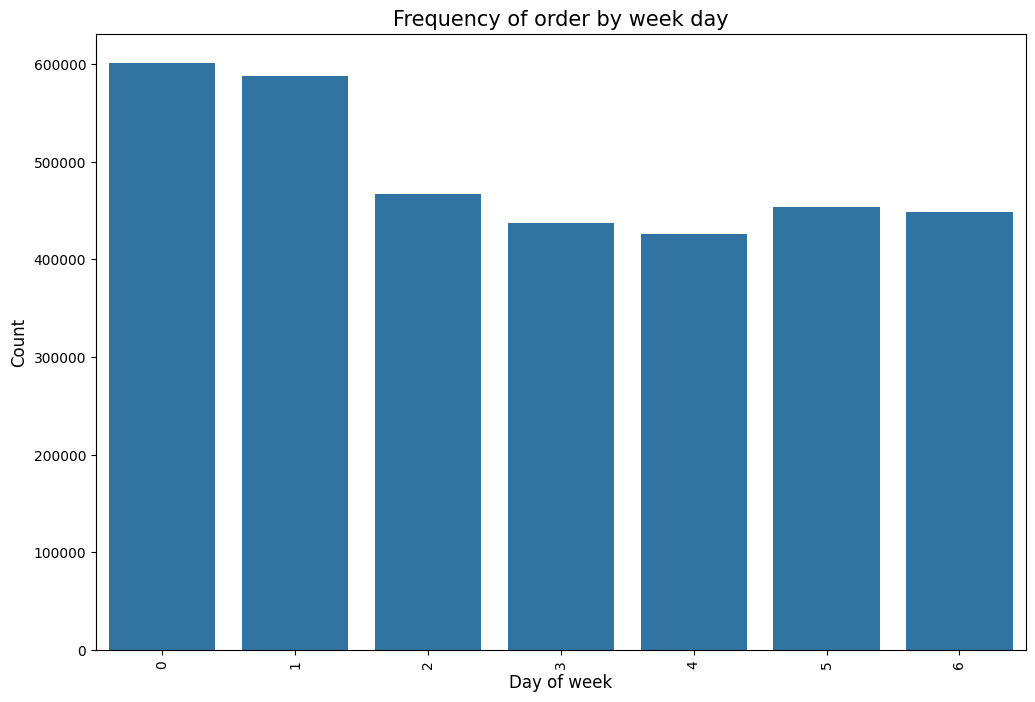

In [9]:
plt.figure(figsize = (12, 8))
sns.countplot(x = "order_dow", data = orders_df, color = color[0])
plt.ylabel("Count", fontsize = 12)
plt.xlabel("Day of week", fontsize = 12)
plt.xticks(rotation = "vertical")
plt.title("Frequency of order by week day", fontsize = 15)
plt.show()

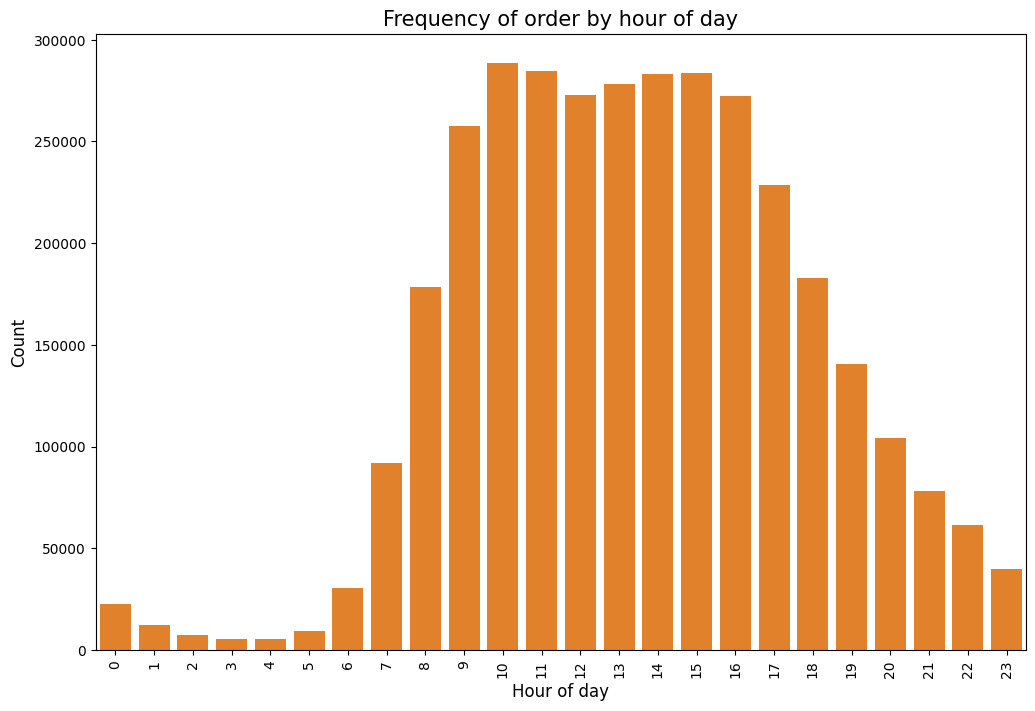

In [10]:
plt.figure(figsize = (12, 8))
sns.countplot(x = "order_hour_of_day", data = orders_df, color = color[1])
plt.ylabel("Count", fontsize = 12)
plt.xlabel("Hour of day", fontsize = 12)
plt.xticks(rotation = "vertical")
plt.title("Frequency of order by hour of day", fontsize = 15)
plt.show()

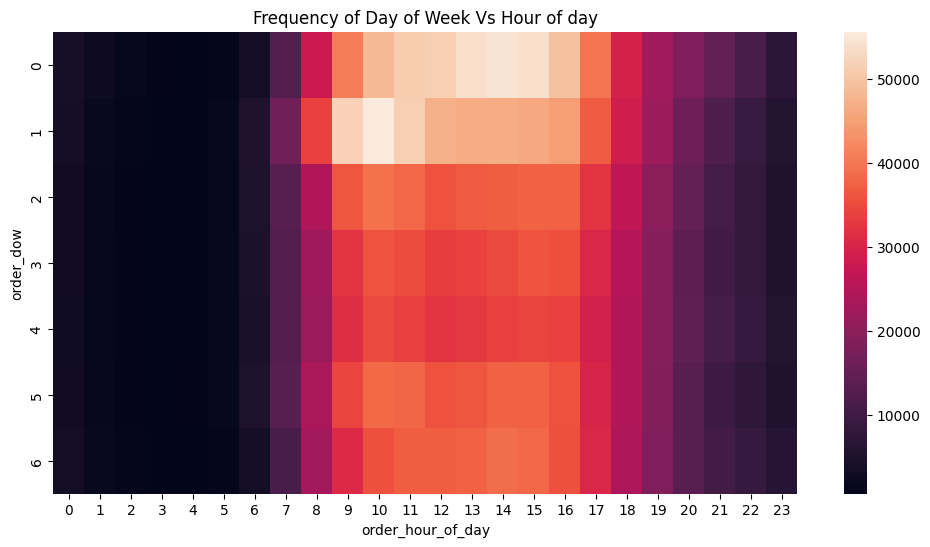

In [11]:
grouped_df = orders_df.groupby(["order_dow", "order_hour_of_day"])["order_number"].aggregate("count").reset_index()
grouped_df = grouped_df.pivot(index = 'order_dow', columns = 'order_hour_of_day', values = 'order_number')

plt.figure(figsize = (12, 6))
sns.heatmap(grouped_df)
plt.title("Frequency of Day of Week Vs Hour of day")
plt.show()

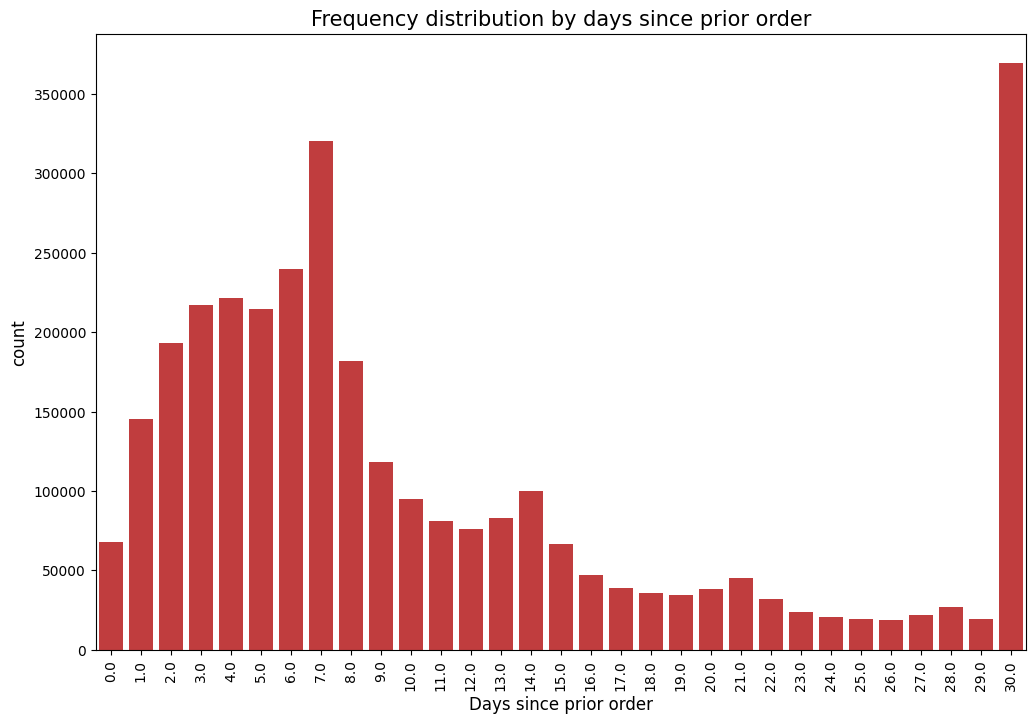

In [12]:
plt.figure(figsize = (12, 8))
sns.countplot(x = "days_since_prior_order", data = orders_df, color = color[3])
plt.ylabel("count", fontsize = 12)
plt.xlabel('Days since prior order', fontsize = 12)
plt.xticks(rotation = 'vertical')
plt.title("Frequency distribution by days since prior order", fontsize = 15)
plt.show()

In [13]:
# percentage of re-orders in prior set #
order_products_prior_df.reordered.sum() / order_products_prior_df.shape[0]

np.float64(0.5896974667922161)

In [14]:
# percentage of re_orders in train set #
order_products_train_df.reordered.sum() / order_products_train_df.shape[0]

np.float64(0.5985944127509629)

In [15]:
grouped_df = order_products_prior_df.groupby("order_id")["reordered"].aggregate(
    "sum").reset_index()
grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1
grouped_df.reordered.value_counts() / grouped_df.shape[0]

/tmp/ipykernel_14107/3903255187.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1


,count
reordered,
1,0.879151
0,0.120849


In [16]:
grouped_df = order_products_train_df.groupby("order_id")["reordered"].aggregate(
    "sum").reset_index()
grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1
grouped_df.reordered.value_counts() / grouped_df.shape[0]

/tmp/ipykernel_14107/3415188268.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1


,count
reordered,
1,0.93444
0,0.06556


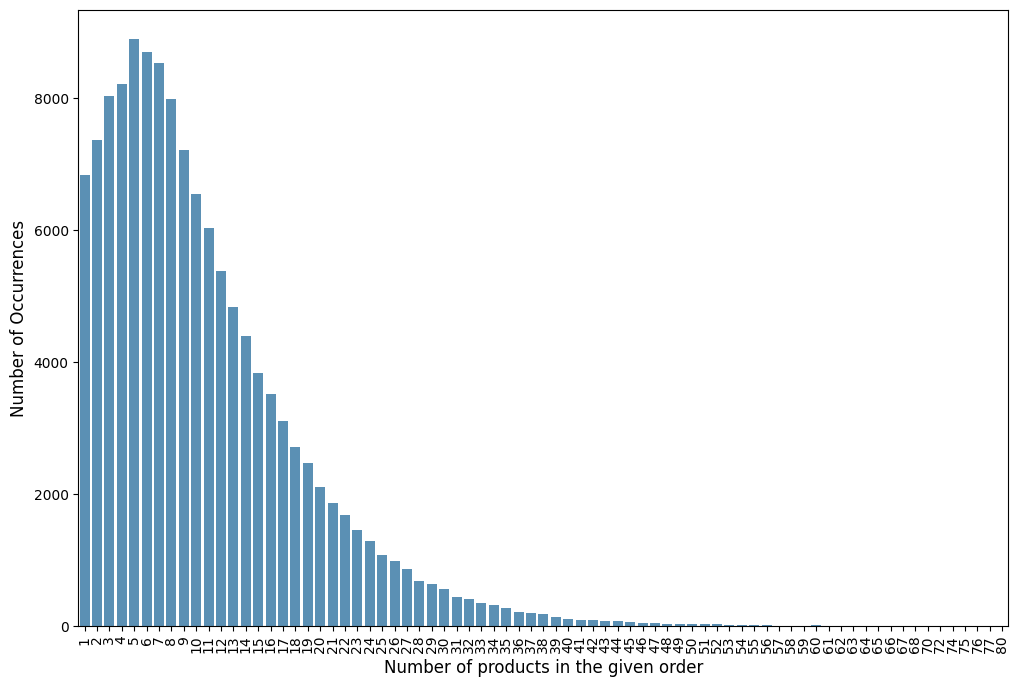

In [17]:
grouped_df = order_products_train_df.groupby("order_id")["add_to_cart_order"].aggregate("max").reset_index()
cnt_srs = grouped_df.add_to_cart_order.value_counts()

plt.figure(figsize = (12, 8))
sns.barplot(x = cnt_srs.index, y = cnt_srs.values, alpha = 0.8)
plt.ylabel("Number of Occurrences", fontsize = 12)
plt.xlabel("Number of products in the given order", fontsize = 12)
plt.xticks(rotation = "vertical")
plt.show()

In [18]:
products_df.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [19]:
aisles_df.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [20]:
departments_df.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [21]:
order_products_prior_df = pd.merge(order_products_prior_df, products_df,
                                   on = 'product_id', how = 'left')
order_products_prior_df = pd.merge(order_products_prior_df, aisles_df,
                                   on = 'aisle_id', how = 'left')
order_products_prior_df = pd.merge(order_products_prior_df, departments_df,
                                   on = 'department_id', how = 'left')
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


In [22]:
cnt_srs = order_products_prior_df['product_name'].value_counts().reset_index().head(20)
cnt_srs.columns = ['product_name', 'frequency_count']
cnt_srs

,product_name,frequency_count
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
5,Organic Avocado,176815
6,Large Lemon,152657
7,Strawberries,142951
8,Limes,140627
9,Organic Whole Milk,137905


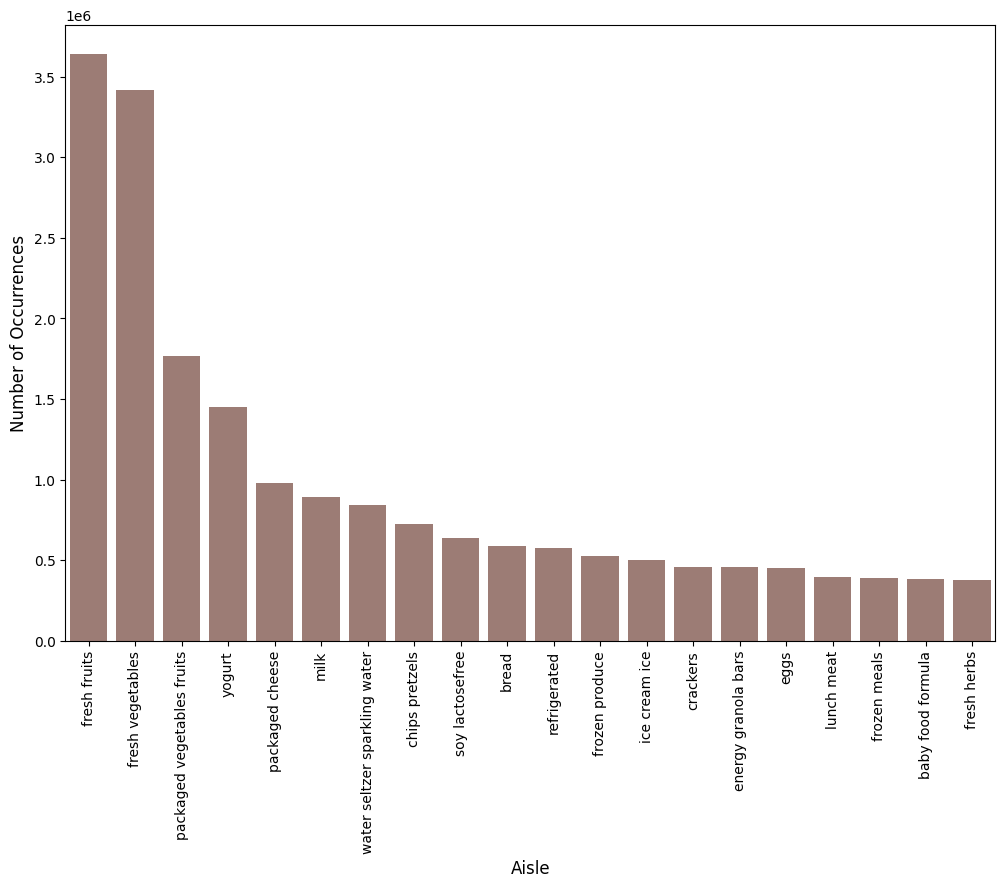

In [23]:
cnt_srs = order_products_prior_df['aisle'].value_counts().head(20)
plt.figure(figsize = (12, 8))
sns.barplot(x = cnt_srs.index, y = cnt_srs.values, alpha = 0.8, color = color[5])
plt.ylabel("Number of Occurrences", fontsize = 12)
plt.xlabel("Aisle", fontsize = 12)
plt.xticks(rotation = 'vertical')
plt.show()

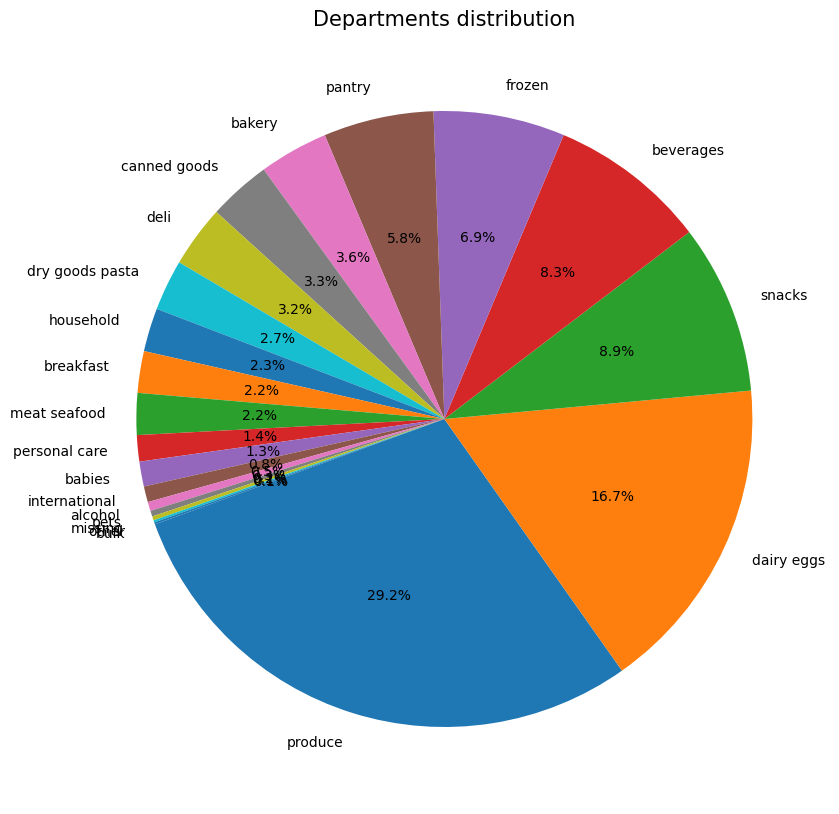

In [24]:
plt.figure(figsize = (10, 10))
temp_series = order_products_prior_df['department'].value_counts()
labels = (np.array(temp_series.index))
sizes = (np.array((temp_series / temp_series.sum())*100))
plt.pie(sizes, labels = labels, autopct = '%1.1f%%', startangle = 200)
plt.title("Departments distribution", fontsize = 15)
plt.show()

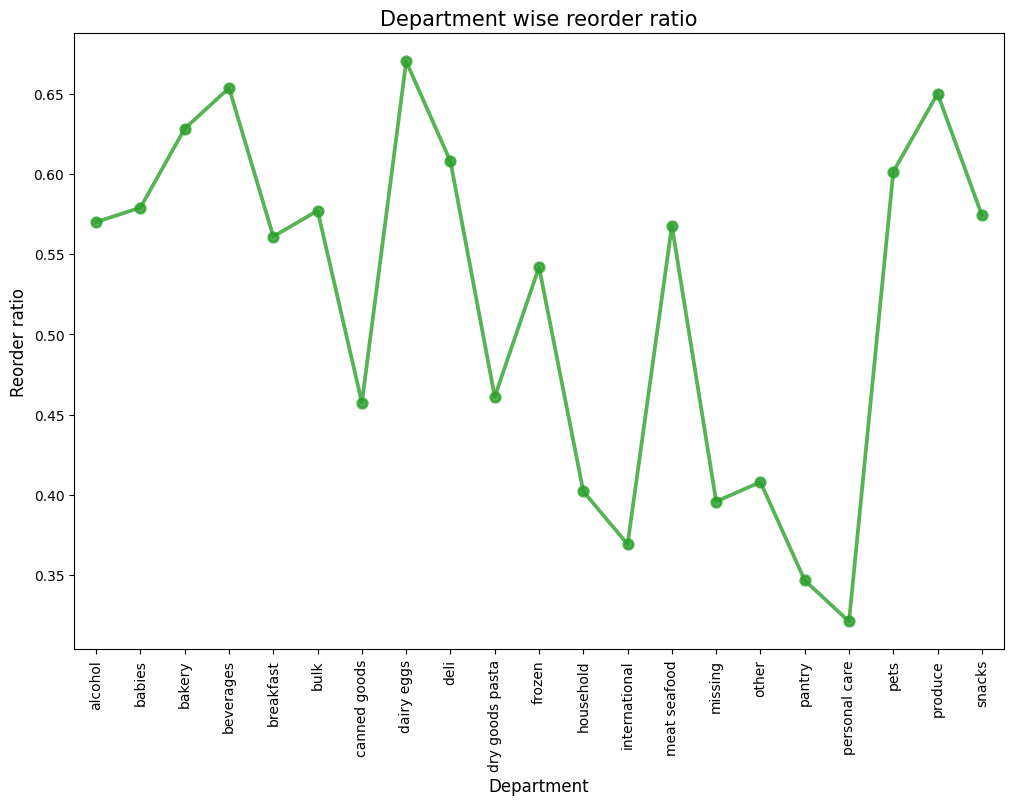

In [25]:
grouped_df = order_products_prior_df.groupby(["department"])["reordered"].aggregate(
    "mean").reset_index()

plt.figure(figsize = (12, 8))
sns.pointplot(x = grouped_df['department'].values, y = grouped_df['reordered'].values,
              alpha = 0.8, color = color[2])
plt.ylabel("Reorder ratio", fontsize = 12)
plt.xlabel("Department", fontsize = 12)
plt.title("Department wise reorder ratio", fontsize = 15)
plt.xticks(rotation = 'vertical')
plt.show()

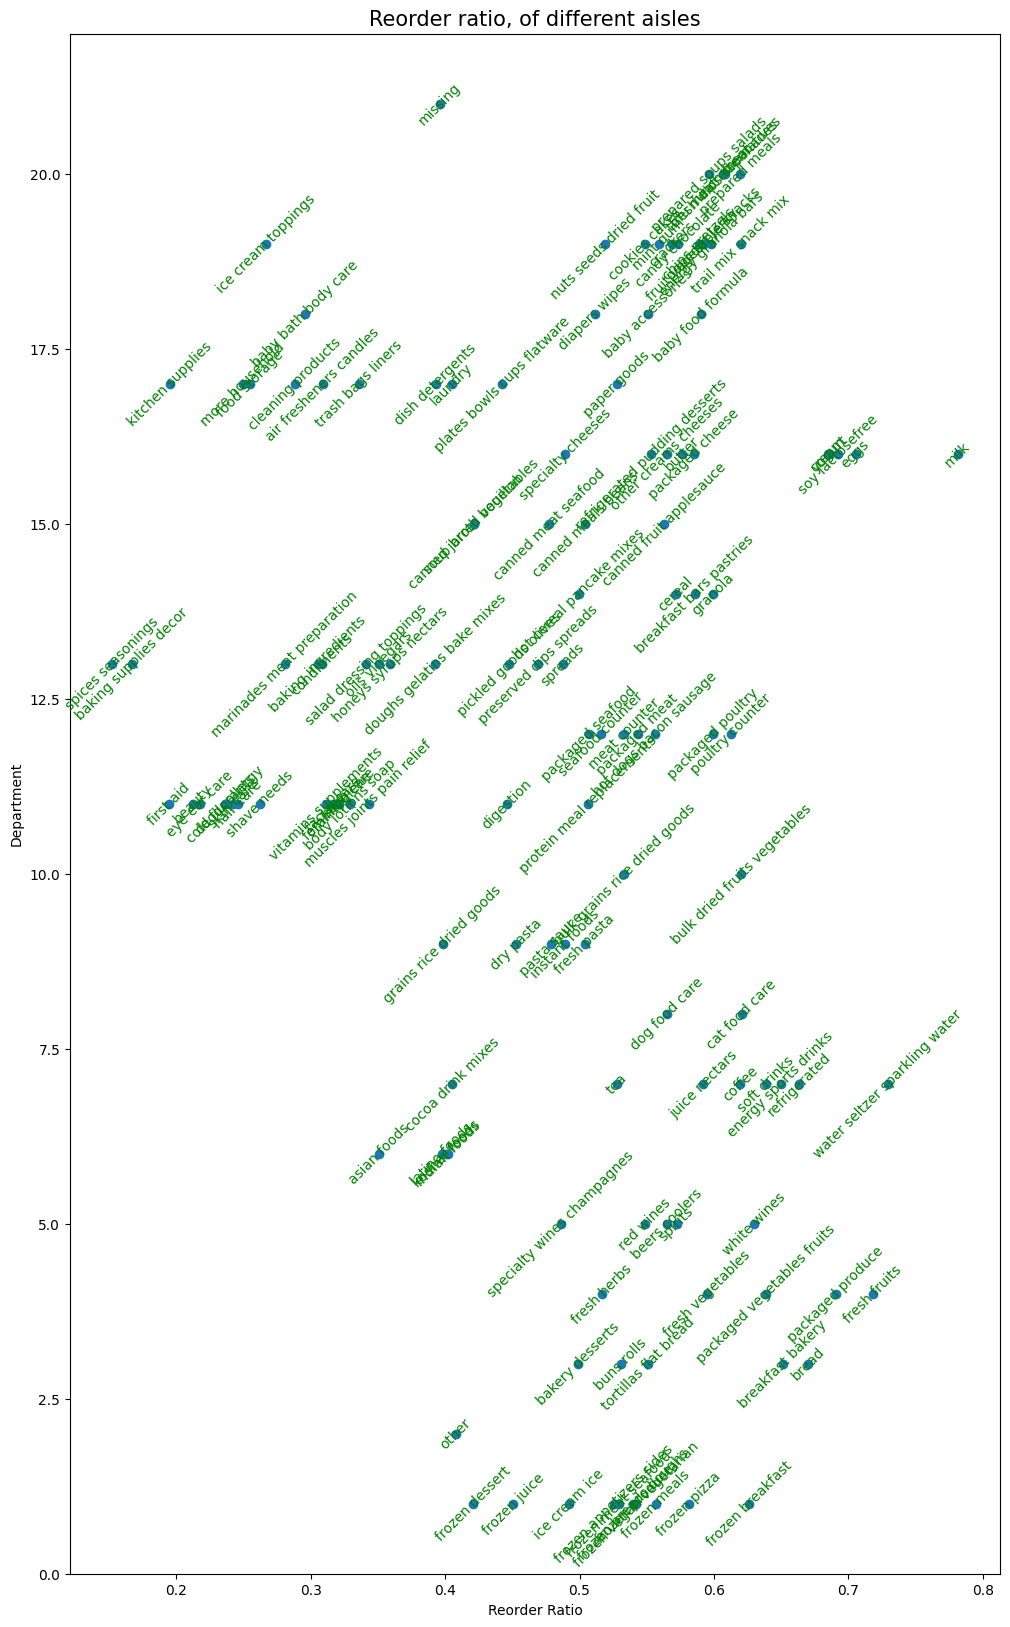

In [26]:
grouped_df = order_products_prior_df.groupby(["department_id", "aisle"])["reordered"].aggregate(
    "mean").reset_index()

fig, ax = plt.subplots(figsize = (12, 20))
ax.scatter(grouped_df.reordered.values, grouped_df.department_id.values)
for i, txt in enumerate(grouped_df.aisle.values):
  ax.annotate(txt, (grouped_df.reordered.values[i], grouped_df.department_id.values[i]),
              rotation = 45, ha = 'center', va = 'center', color = 'green')
plt.xlabel("Reorder Ratio")
plt.ylabel("Department")
plt.title("Reorder ratio, of different aisles", fontsize = 15)
plt.show()

/tmp/ipykernel_14107/2325252689.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  order_products_prior_df["add_to_cart_order_mod"].loc[order_products_prior_df["add_to_cart_order_mod"]>70] = 70


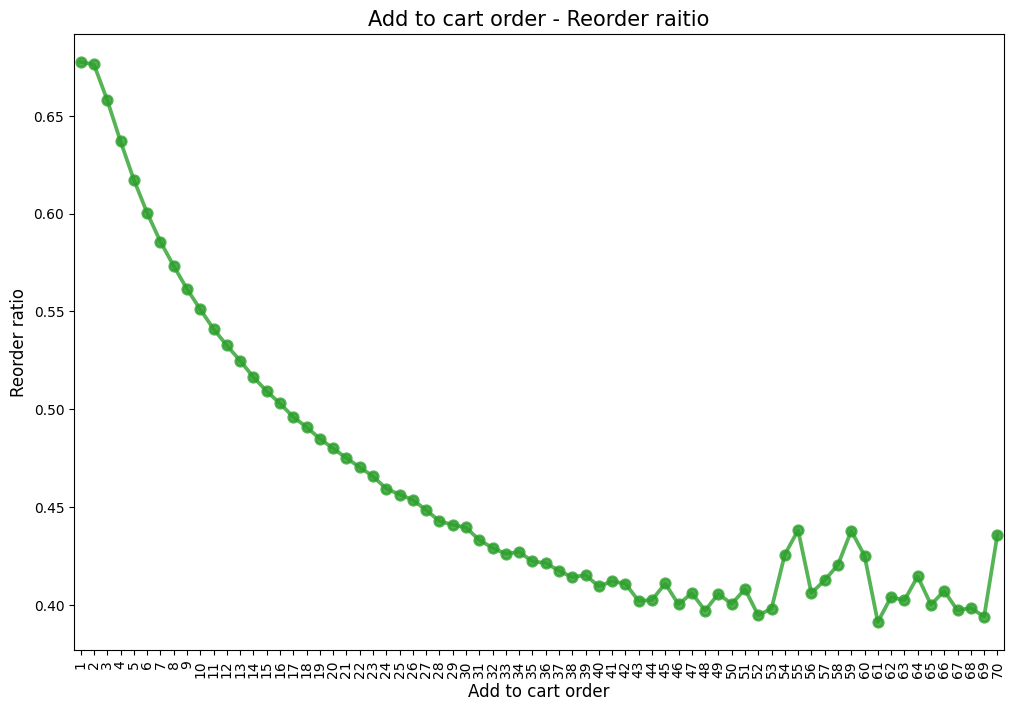

In [27]:
order_products_prior_df["add_to_cart_order_mod"] = order_products_prior_df["add_to_cart_order"].copy()
order_products_prior_df["add_to_cart_order_mod"].loc[order_products_prior_df["add_to_cart_order_mod"]>70] = 70
grouped_df = order_products_prior_df.groupby(["add_to_cart_order_mod"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize = (12, 8))
sns.pointplot(x = grouped_df["add_to_cart_order_mod"].values,
              y = grouped_df["reordered"].values, alpha = 0.8, color = color[2])
plt.ylabel("Reorder ratio", fontsize = 12)
plt.xlabel("Add to cart order", fontsize = 12)
plt.title("Add to cart order - Reorder raitio", fontsize = 15)
plt.xticks(rotation = "vertical")
plt.show()

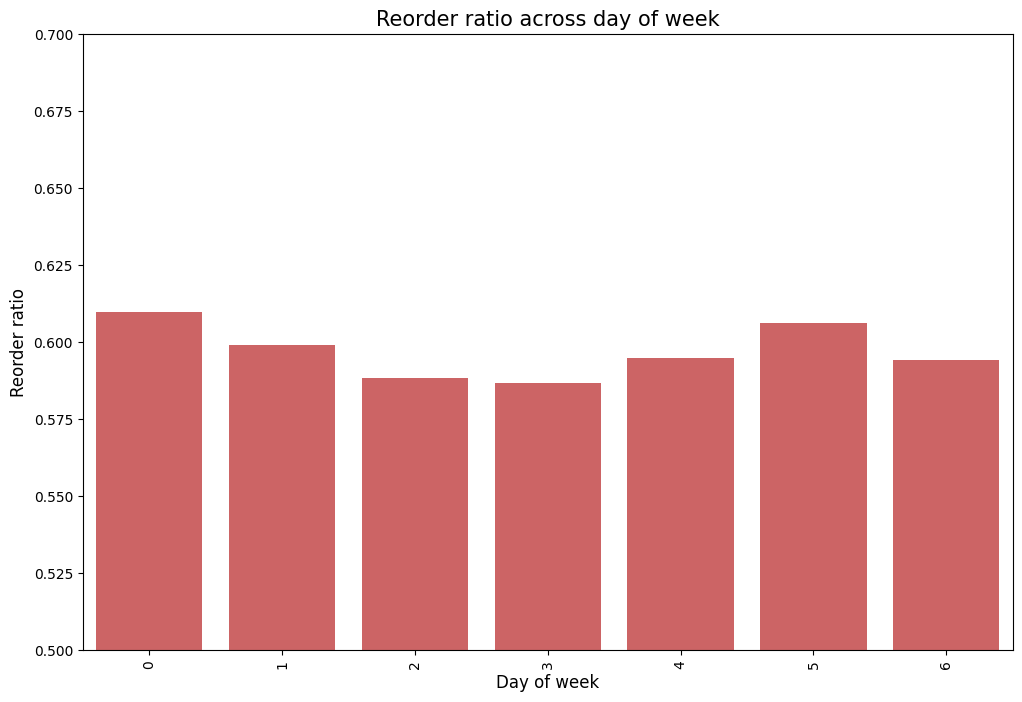

In [28]:
order_products_train_df = pd.merge(order_products_train_df, orders_df,
                                   on = 'order_id', how = 'left')
grouped_df = order_products_train_df.groupby(["order_dow"])["reordered"].aggregate(
    "mean").reset_index()

plt.figure(figsize = (12, 8))
sns.barplot(x = grouped_df['order_dow'].values, y = grouped_df['reordered'].values,
            alpha = 0.8, color = color[3])
plt.ylabel('Reorder ratio', fontsize = 12)
plt.xlabel('Day of week', fontsize = 12)
plt.title("Reorder ratio across day of week", fontsize = 15)
plt.xticks(rotation = 'vertical')
plt.ylim(0.5, 0.7)
plt.show()

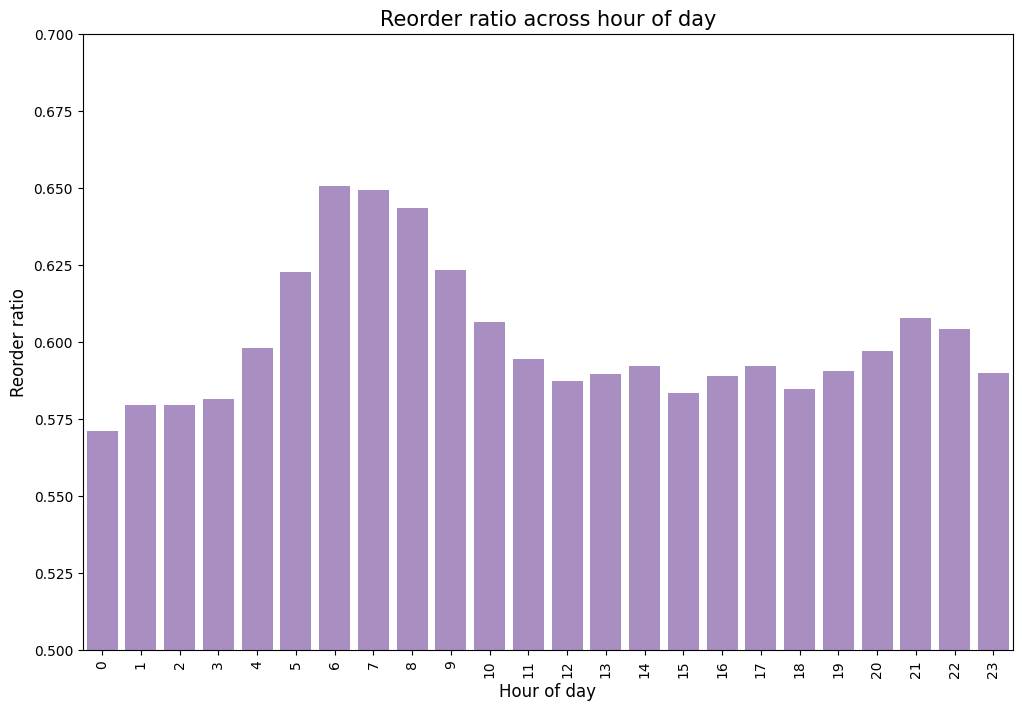

In [29]:
grouped_df = order_products_train_df.groupby(["order_hour_of_day"])["reordered"].aggregate(
    "mean").reset_index()

plt.figure(figsize = (12, 8))
sns.barplot(x = grouped_df['order_hour_of_day'].values, y = grouped_df["reordered"].values,
            alpha = 0.8, color = color[4])
plt.ylabel("Reorder ratio", fontsize = 12)
plt.xlabel("Hour of day", fontsize = 12)
plt.title("Reorder ratio across hour of day", fontsize = 15)
plt.xticks(rotation = 'vertical')
plt.ylim(0.5, 0.7)
plt.show()

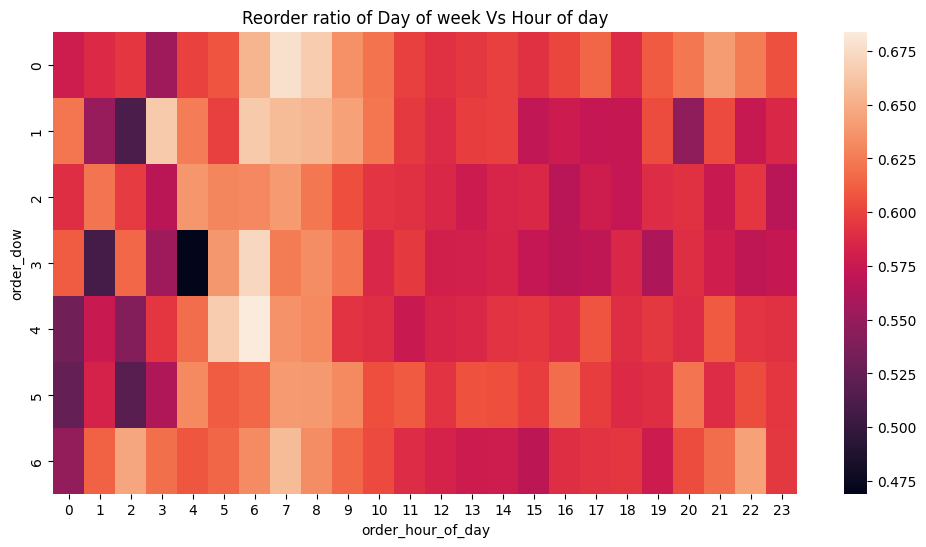

In [30]:
grouped_df = order_products_train_df.groupby(["order_dow", "order_hour_of_day"])[
    "reordered"].aggregate("mean").reset_index()
grouped_df = grouped_df.pivot(index = 'order_dow', columns = 'order_hour_of_day',
                              values = 'reordered')

plt.figure(figsize = (12, 6))
sns.heatmap(grouped_df)
plt.title("Reorder ratio of Day of week Vs Hour of day")
plt.show()

# 개념 정리

Dataframe.column 형식으로도 컬럼을 선택할 수 있음. (컬럼 이름에 공백이 있거나 특정 메서드와 이름이 겹치면 사용 불가한 단점이 있어 대괄호 방식이 더 권장됨.)  
plt.xticks(rotation = 'vertical')로 x축의 글자들을 세로로 세워서 나타낼 수 있음.  
groupby 연산을 수행할 때 기준이 되는 컬럼이 자동으로 인덱스로 들어가는데, 이를 일반 컬럼으로 빼내기 위해 reset_index()를 같이 쓰는 경우가 많음.  
Heatmap 그래프는 상관관계 뿐만 아니라 두 개의 변수 사이 빈도를 시각화하는 데도 사용됨.  
pointplot : 평균값을 점으로 나타내고 선으로 이은 그래프. sns.pointplot() 함수 사용.  
ax.annotate(text, (x, y), rotation, ha, va, color, ...) 함수로 그래프에 주석을 달 수 있음. enumerate 반복문을 통해 산점도의 모든 점에 이름을 달아주는 등으로 활용.

# 추가 분석

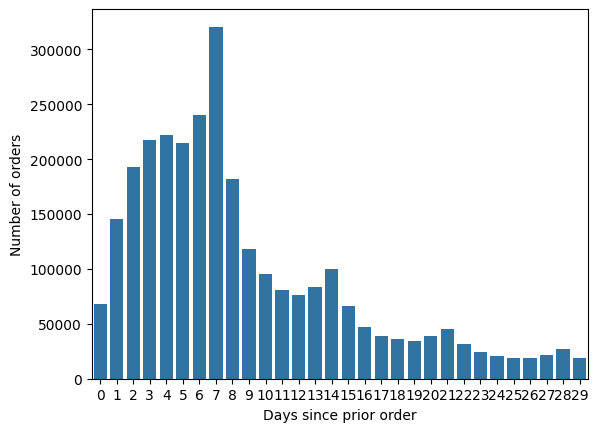

In [39]:
cnt_srs = orders_df["days_since_prior_order"].value_counts().reset_index()
cnt_srs = cnt_srs[cnt_srs["days_since_prior_order"] < 30]
cnt_srs["days_since_prior_order"] = cnt_srs["days_since_prior_order"].astype(int)

sns.barplot(x = cnt_srs["days_since_prior_order"], y = cnt_srs["count"])
plt.xlabel("Days since prior order")
plt.ylabel("Number of orders")
plt.show()

재주문을 한 경우 몇 일이 지난 후 재주문을 하는 경우가 많은지 분석해보았다. 30일 이상은 모두 30일로 처리되어 긴 기간은 30일에 몰려있기 때문에 해당 데이터를 제외하고 bar plot을 그렸다.  
1~8일 간격으로 재주문을 한 경우가 많았고, 특히 7일 간격이 제일 많았다. 재주문을 한 경우 일주일의 짧은 기간 내에 하는 경우가 많았다는 것을 알 수 있다.